# SupplyPrescript - Exploratory Data Analysis (EDA)

This notebook performs the initial exploratory data analysis for the SupplyPrescript project. The objective is to understand the dataset, identify data quality issues, analyze the target variable, and prepare the data for machine learning.

## 1. Import Required Libraries

In [158]:
import pandas as pd
import numpy as np

## 2. Load the Dataset

In [159]:
df = pd.read_csv("../data/dynamic_supply_chain_logistics_dataset_with_country.csv")

## 3. Dataset Overview

## 3.1 Display First Five Rows

In [160]:
# Display the first five rows
df.head()

,warehouse_inventory_level,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,cargo_condition_status,route_risk_level,customs_clearance_time,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,product_id,supplier_id,supplier_country
0,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S1,Greece
1,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S2,South Korea
2,985.716862,0.481294,0.761166,0.359066,456.503853,0.986064,2.128009,100.772854,0.777263,1.182116,0.502006,0.506152,0.885291,Moderate Risk,9.110682,P0353,P0353_S3,Ethiopia
3,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,High Risk,8.175281,P0857,P0857_S1,Iran
4,396.700206,0.620780,0.196594,0.230660,640.408205,0.463233,12.608166,5313.738114,0.091839,9.611988,0.966774,0.980784,0.544178,High Risk,8.175281,P0857,P0857_S2,Guatemala


## 3.2 Dataset Shape

In [161]:
# Check the number of rows and columns
df.shape

(113097, 18)

## 3.3 Column Names

In [162]:
df.columns

Index(['warehouse_inventory_level', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'shipping_costs', 'supplier_reliability_score', 'lead_time_days',
       'historical_demand', 'cargo_condition_status', 'route_risk_level',
       'customs_clearance_time', 'disruption_likelihood_score',
       'delay_probability', 'risk_classification', 'delivery_time_deviation',
       'product_id', 'supplier_id', 'supplier_country'],
      dtype='object')

## 3.4 Dataset Information

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113097 entries, 0 to 113096
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   warehouse_inventory_level        113097 non-null  float64
 1   handling_equipment_availability  113097 non-null  float64
 2   order_fulfillment_status         113097 non-null  float64
 3   weather_condition_severity       113097 non-null  float64
 4   shipping_costs                   113097 non-null  float64
 5   supplier_reliability_score       113097 non-null  float64
 6   lead_time_days                   113097 non-null  float64
 7   historical_demand                113097 non-null  float64
 8   cargo_condition_status           113097 non-null  float64
 9   route_risk_level                 113097 non-null  float64
 10  customs_clearance_time           113097 non-null  float64
 11  disruption_likelihood_score      113097 non-null  float64
 12  de

## 4. Target Variable Analysis

In [164]:
# Count of each risk category
df["risk_classification"].value_counts()

risk_classification
High Risk        84368
Moderate Risk    17783
Low Risk         10946
Name: count, dtype: int64

In [165]:
# Percentage of each risk category
df["risk_classification"].value_counts(normalize=True) * 100

risk_classification
High Risk        74.597912
Moderate Risk    15.723671
Low Risk          9.678418
Name: proportion, dtype: float64

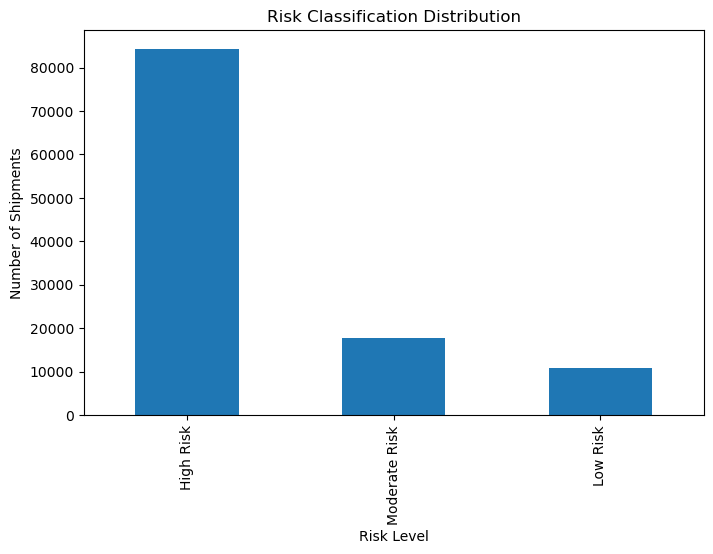

In [166]:
# Bar chart of risk categories
plt.figure(figsize=(8,5))
df["risk_classification"].value_counts().plot(kind="bar")

plt.title("Risk Classification Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Shipments")

plt.show()

## 5. Data Quality Check

In [167]:
df.duplicated().sum()

np.int64(0)

## 6. Summary Statistics

In [168]:
df.describe()

,warehouse_inventory_level,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,cargo_condition_status,route_risk_level,customs_clearance_time,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,1.130970e+05,1.130970e+05,113097.000000,1.130970e+05,113097.000000,1.130970e+05,113097.000000,113097.000000,1.130970e+05,113097.000000,113097.000000,113097.000000,113097.000000,113097.000000
mean,3.003784e+02,3.035988e-01,0.600992,4.978949e-01,459.696347,5.007075e-01,5.216388,6019.928559,2.972676e-01,6.996506,2.296624,0.803447,0.699617,5.170553
std,3.238605e+02,3.265116e-01,0.345996,3.534547e-01,312.319187,3.539325e-01,4.517152,3429.394766,3.215012e-01,3.236633,1.555277,0.279062,0.324297,4.158751
min,1.320000e-12,4.570000e-16,0.000001,4.540000e-09,100.000000,6.900000e-10,1.000000,100.002966,7.260000e-19,0.000050,0.500000,0.000048,0.000003,-1.999998
25%,1.629617e+01,1.729129e-02,0.276788,1.441563e-01,153.869113,1.444370e-01,1.237201,2821.510422,1.684023e-02,4.581787,0.777328,0.691751,0.456054,1.259607
50%,1.591262e+02,1.596415e-01,0.681859,4.979655e-01,389.202356,5.028767e-01,3.282951,6786.803625,1.553862e-01,8.376387,1.942439,0.958108,0.840807,6.088516
75%,5.425833e+02,5.565744e-01,0.938873,8.507550e-01,754.167627,8.548505e-01,8.611542,9372.022086,5.400466e-01,9.835310,3.749471,0.998764,0.982401,9.247708
max,9.999993e+02,9.999995e-01,1.000000,1.000000e+00,999.999853,1.000000e+00,14.999995,10000.000000,1.000000e+00,10.000000,5.000000,1.000000,1.000000,10.000000


## 7. Data Visualization

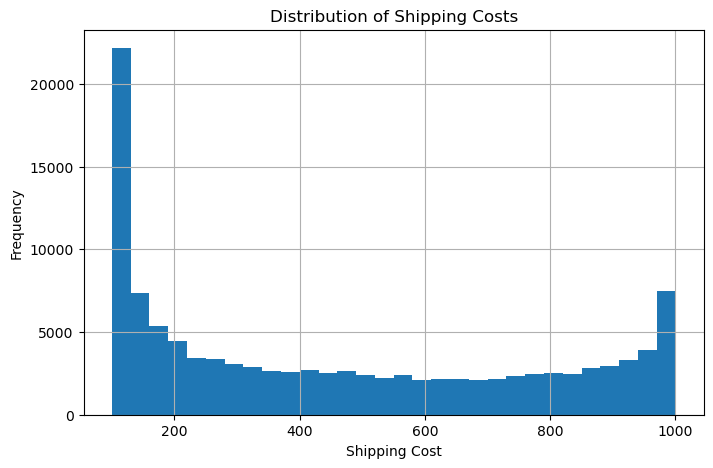

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["shipping_costs"].hist(bins=30)

plt.title("Distribution of Shipping Costs")
plt.xlabel("Shipping Cost")
plt.ylabel("Frequency")

plt.savefig("../reports/shipping_cost_distribution.png")
plt.show()

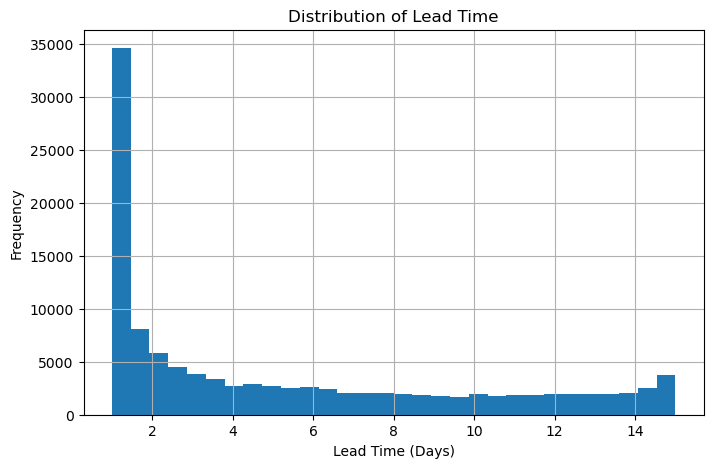

In [170]:
plt.figure(figsize=(8,5))

df["lead_time_days"].hist(bins=30)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.savefig("../reports/lead_time_distribution.png")
plt.show()

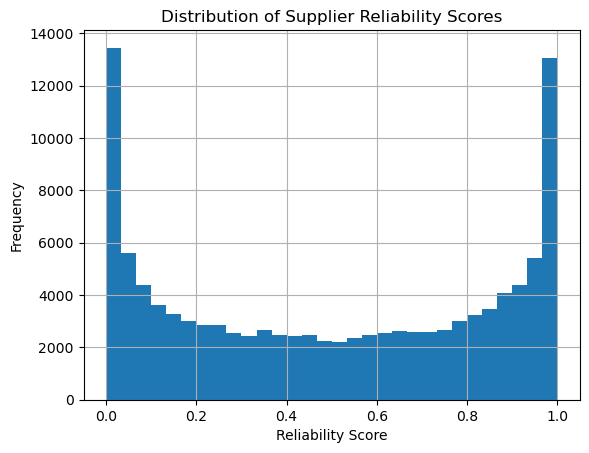

In [171]:
df["supplier_reliability_score"].hist(bins=30)
plt.title("Distribution of Supplier Reliability Scores")
plt.xlabel("Reliability Score")
plt.ylabel("Frequency")

plt.savefig("../reports/supplier_reliability_distribution.png")
plt.show()

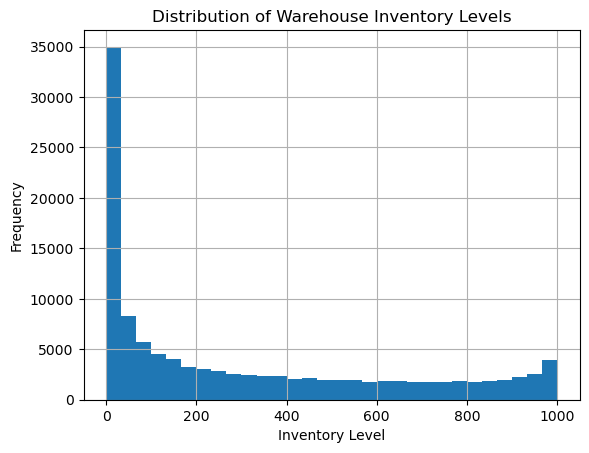

In [172]:
df["warehouse_inventory_level"].hist(bins=30)
plt.title("Distribution of Warehouse Inventory Levels")
plt.xlabel("Inventory Level")
plt.ylabel("Frequency")

plt.savefig("../reports/warehouse_inventory_distribution.png")
plt.show()

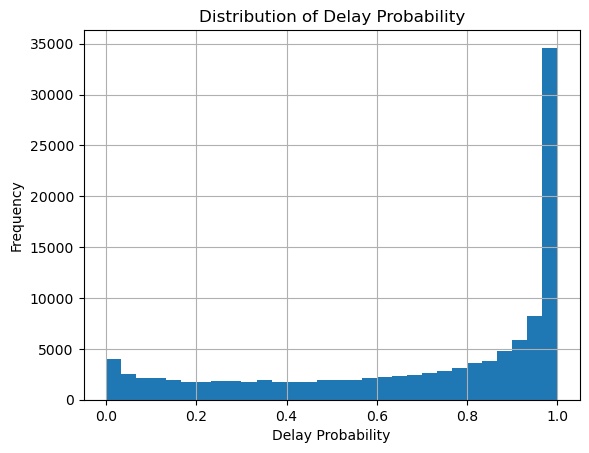

In [173]:
df["delay_probability"].hist(bins=30)
plt.title("Distribution of Delay Probability")
plt.xlabel("Delay Probability")
plt.ylabel("Frequency")

plt.savefig("../reports/delay_probability_distribution.png")
plt.show()

## 8. Correlation Analysis

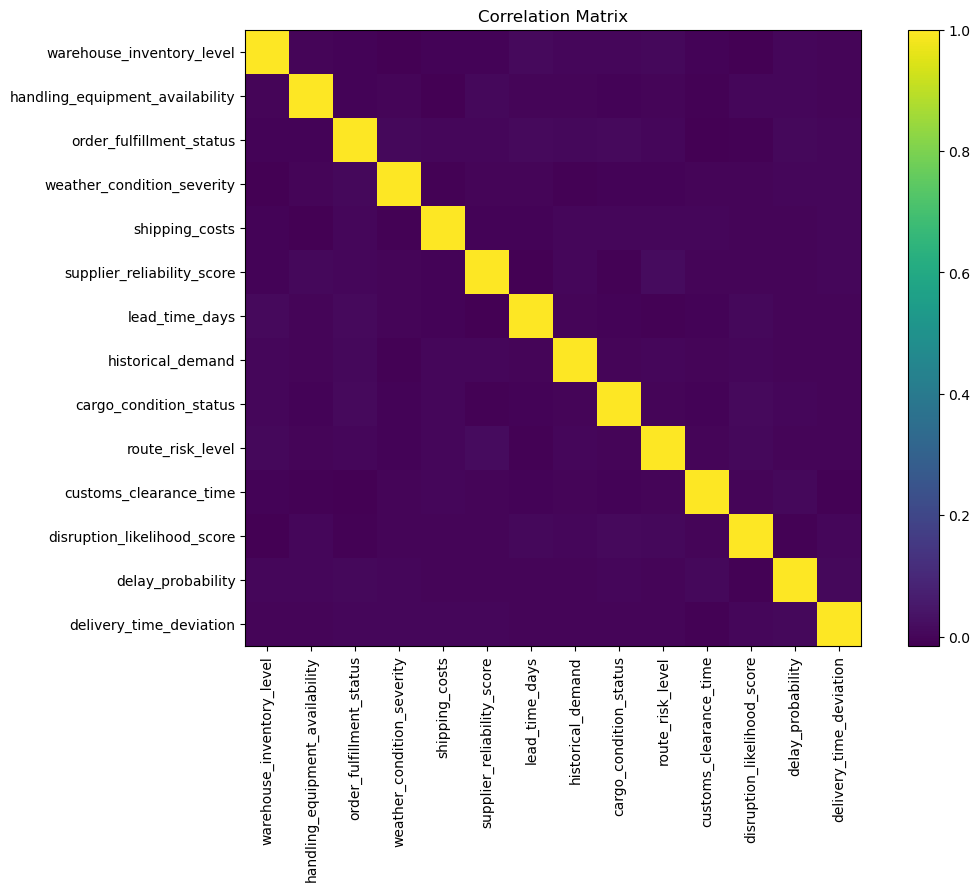

In [174]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(correlation)
plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.savefig("../reports/correlation_matrix.png")
plt.title("Correlation Matrix")
plt.show()

## 9. Key Findings

- Dataset contains 113,097 records and 18 columns.
- No missing values were found.
- No duplicate records were found.
- The target variable (risk_classification) is imbalanced:
  - High Risk: 74.60%
  - Moderate Risk: 15.72%
  - Low Risk: 9.68%
- Further preprocessing will focus on encoding categorical variables and handling class imbalance before model training.